# CH 5 - 3 : CONFIRMATORY EVIDENCE: IT'S NICE, IT'S NECESSARY, BUT IT AIN'T SUFFICIENT

## Objectif pédagogique

Ce cahier illustre une idée centrale de David Aronson : **une preuve confirmatoire est nécessaire, mais elle n’est pas suffisante**.

En trading, cela veut dire :

> Un backtest profitable est nécessaire pour considérer une stratégie intéressante, mais il ne prouve pas à lui seul que la stratégie possède un vrai edge.

Le profit passé peut venir de deux sources très différentes :

1. **Un vrai pouvoir prédictif**
2. **La chance, le hasard, ou la variabilité d’échantillonnage**

L’objectif de ce notebook est de rendre cette différence visible avec du code Python.

## 1. L’erreur logique : affirmation du conséquent

La logique intuitive du trader débutant ressemble souvent à ceci :

- Si ma règle a un edge, alors elle devrait gagner en backtest.
- Mon backtest gagne.
- Donc ma règle a un edge.

Le problème est que cette conclusion est invalide.

Pourquoi ? Parce qu’un backtest gagnant peut aussi apparaître **sans edge**, simplement par chance.

C’est ce qu’on appelle l’**affirmation du conséquent**.

Forme logique :

- Si `P`, alors `Q`
- `Q`
- Donc `P`

Cette forme est invalide.

Exemple trading :

- Si la stratégie a un edge, alors elle peut faire du profit.
- Elle a fait du profit.
- Donc elle a un edge.

Conclusion trop rapide.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 2. Simulation simple : une stratégie sans edge peut gagner

On va simuler une stratégie qui n’a **aucun edge réel**.

Chaque trade a une espérance de gain égale à zéro.

Cela signifie que, théoriquement, la stratégie n’a aucun pouvoir prédictif.

Mais à cause du hasard, elle peut quand même finir positive sur un échantillon limité.

Résultat final du backtest sans edge : -0.61 R
Moyenne par trade : -0.0024 R


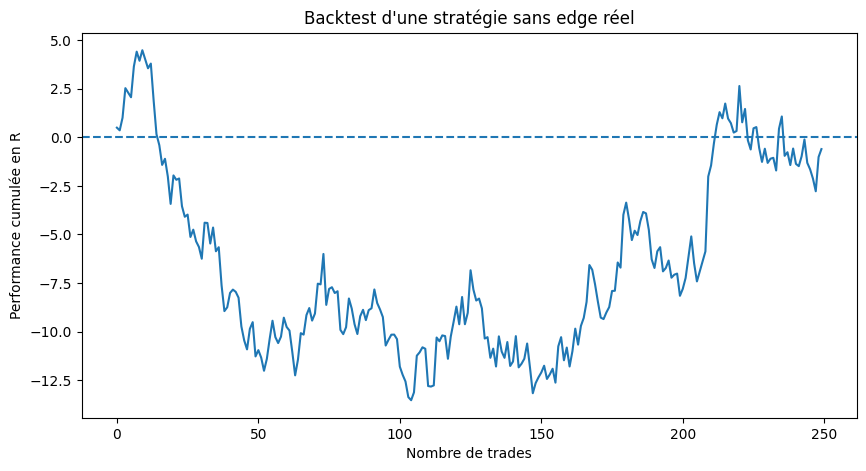

In [2]:
n_trades = 250

# Stratégie sans edge : rendements aléatoires centrés sur 0
returns_no_edge = np.random.normal(loc=0.0, scale=1.0, size=n_trades)

equity_no_edge = returns_no_edge.cumsum()

print(f"Résultat final du backtest sans edge : {equity_no_edge[-1]:.2f} R")
print(f"Moyenne par trade : {returns_no_edge.mean():.4f} R")

plt.figure(figsize=(10, 5))
plt.plot(equity_no_edge)
plt.axhline(0, linestyle="--")
plt.title("Backtest d'une stratégie sans edge réel")
plt.xlabel("Nombre de trades")
plt.ylabel("Performance cumulée en R")
plt.show()

## Interprétation

Même si la stratégie n’a aucun edge, la courbe peut temporairement monter.

Ce genre de résultat peut piéger le trader.

Il peut regarder la courbe et penser :

> “Ma stratégie fonctionne.”

Mais scientifiquement, le bon réflexe est plutôt :

> “Est-ce que ce profit est trop grand pour être expliqué par la chance ?”

C’est exactement la question derrière les tests statistiques.

## 3. Plusieurs stratégies aléatoires : le piège devient énorme

Maintenant, imaginons qu’un trader teste 1 000 variantes de règles :

- différents horaires,
- différents filtres,
- différents niveaux de stop-loss,
- différentes conditions d’entrée,
- différents actifs.

Aucune stratégie n’a de vrai edge.

Mais si on en teste beaucoup, certaines vont forcément sembler excellentes par hasard.

Meilleure performance parmi 1000 stratégies sans edge : 44.79 R
Moyenne par trade de cette meilleure stratégie : 0.1792 R


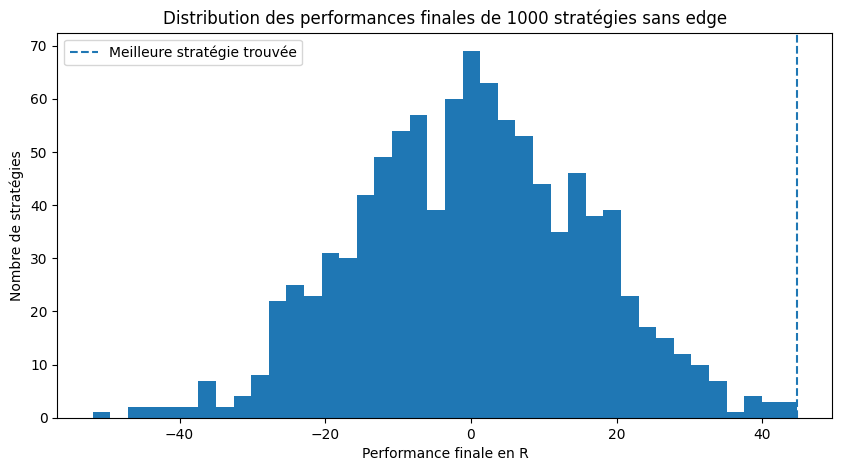

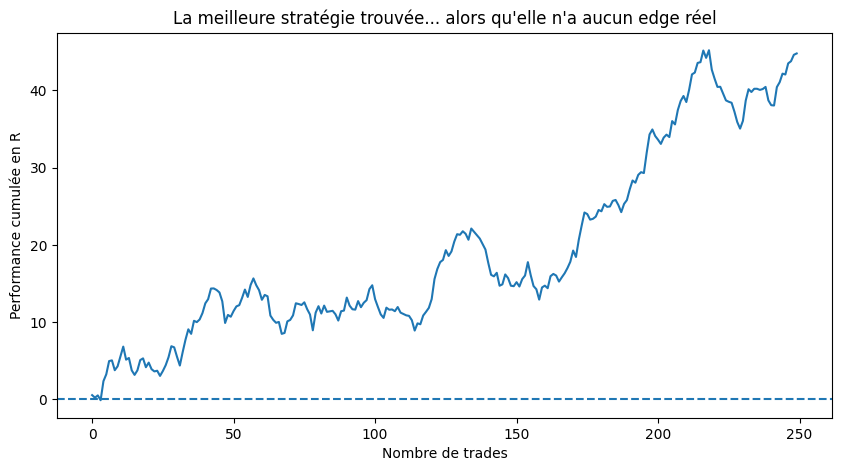

In [3]:
n_strategies = 1000
n_trades = 250

# 1000 stratégies sans edge réel
all_returns = np.random.normal(loc=0.0, scale=1.0, size=(n_strategies, n_trades))
final_performances = all_returns.sum(axis=1)

best_index = np.argmax(final_performances)
best_returns = all_returns[best_index]
best_equity = best_returns.cumsum()

print(f"Meilleure performance parmi {n_strategies} stratégies sans edge : {final_performances[best_index]:.2f} R")
print(f"Moyenne par trade de cette meilleure stratégie : {best_returns.mean():.4f} R")

plt.figure(figsize=(10, 5))
plt.hist(final_performances, bins=40)
plt.axvline(final_performances[best_index], linestyle="--", label="Meilleure stratégie trouvée")
plt.title("Distribution des performances finales de 1000 stratégies sans edge")
plt.xlabel("Performance finale en R")
plt.ylabel("Nombre de stratégies")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(best_equity)
plt.axhline(0, linestyle="--")
plt.title("La meilleure stratégie trouvée... alors qu'elle n'a aucun edge réel")
plt.xlabel("Nombre de trades")
plt.ylabel("Performance cumulée en R")
plt.show()

## Interprétation trading

La meilleure courbe peut avoir l’air très convaincante.

Elle peut sembler :

- régulière,
- rentable,
- exploitable,
- “logique” après coup.

Mais dans cette simulation, on connaît la vérité : **toutes les stratégies sont nulles**.

La stratégie gagnante n’a pas été trouvée parce qu’elle avait un edge.

Elle a été trouvée parce qu’on a testé beaucoup de variantes et qu’on a sélectionné celle qui a eu le plus de chance.

C’est le cœur du problème du data mining.

## 4. Nécessaire ne veut pas dire suffisant

Un profit est nécessaire.

Une stratégie qui perd constamment n’est probablement pas intéressante.

Mais un profit n’est pas suffisant.

On peut résumer ainsi :

| Condition | Signification |
|---|---|
| Backtest profitable | Condition nécessaire |
| Profit statistiquement difficile à expliquer par le hasard | Début de preuve plus sérieuse |
| Résultat robuste hors échantillon | Confirmation plus forte |
| Résultat robuste après coûts, slippage, variations de paramètres | Confirmation encore plus forte |

Le profit seul est une observation.

Il ne dit pas encore si la cause est le talent ou la chance.

## 5. Exemple de p-value par simulation

On va maintenant poser la bonne question :

> Si la stratégie n’avait aucun edge, quelle serait la probabilité d’obtenir une performance au moins aussi bonne par hasard ?

C’est une intuition proche de la p-value.

On prend une performance observée, puis on la compare à une distribution de performances produites par des stratégies sans edge.

Performance observée : 35.00 R
p-value simulée : 0.0152


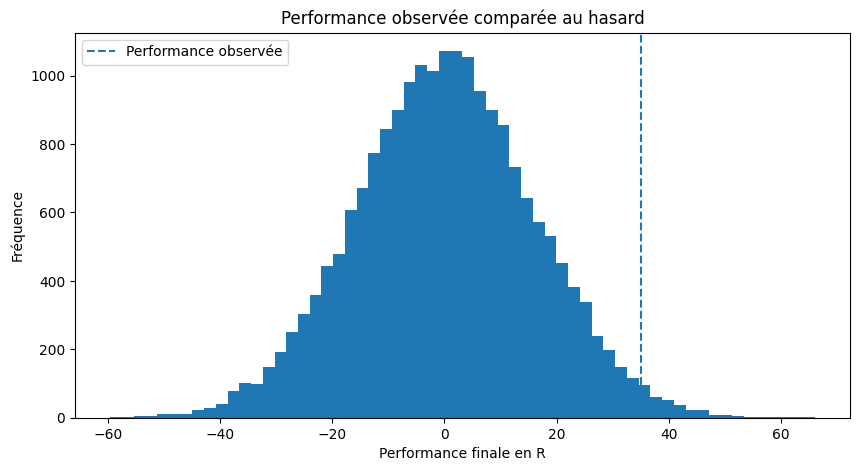

In [4]:
np.random.seed(123)

n_trades = 250
observed_performance = 35  # Exemple : la stratégie observée a gagné +35R

n_simulations = 20000
null_returns = np.random.normal(loc=0.0, scale=1.0, size=(n_simulations, n_trades))
null_final_performances = null_returns.sum(axis=1)

p_value = np.mean(null_final_performances >= observed_performance)

print(f"Performance observée : {observed_performance:.2f} R")
print(f"p-value simulée : {p_value:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(null_final_performances, bins=60)
plt.axvline(observed_performance, linestyle="--", label="Performance observée")
plt.title("Performance observée comparée au hasard")
plt.xlabel("Performance finale en R")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## Interprétation

Si la p-value est faible, cela veut dire :

> Sous l’hypothèse que la stratégie n’a aucun edge, un résultat aussi bon serait rare.

Cela ne prouve pas définitivement que la stratégie est vraie.

Mais cela rend l’explication “pure chance” moins crédible.

La science ne dit pas :

> “La stratégie est vraie.”

Elle dit plutôt :

> “L’hypothèse nulle devient difficile à défendre.”

## 6. La force de la falsification

La pensée scientifique ne cherche pas seulement à confirmer.

Elle cherche à exposer la stratégie à des situations où elle pourrait échouer.

Exemples de falsification en trading :

- Tester sur une autre période.
- Tester sur un autre marché similaire.
- Tester après frais et slippage.
- Tester avec des paramètres légèrement différents.
- Tester hors échantillon.
- Vérifier si l’edge disparaît après un changement de régime.
- Chercher activement les contextes où la règle échoue.

Un trader objectif ne demande pas seulement :

> “Où est-ce que ma stratégie marche ?”

Il demande aussi :

> “Où est-ce qu’elle casse ?”

## 7. Mini-framework EBTA pour analyser un backtest positif

Quand un backtest est profitable, ne concluez pas directement qu’il y a un edge.

Passez par cette grille :

1. **Le profit est-il réel après coûts ?**
2. **Combien de variantes ai-je testées avant de trouver ce résultat ?**
3. **Le résultat est-il robuste aux paramètres ?**
4. **La stratégie fonctionne-t-elle hors échantillon ?**
5. **La performance est-elle statistiquement difficile à expliquer par la chance ?**
6. **Ai-je cherché les cas d’échec aussi sérieusement que les cas de réussite ?**
7. **Est-ce que mon journal mesure objectivement les signaux, ou est-il rempli de narration subjective ?**

Cette discipline protège contre le biais de confirmation.

## 8. Exemple concret : comparaison de deux mentalités

### Mentalité du croyant

> “J’ai trouvé 20 exemples où le setup marche. Donc il est valide.”

Problème : il ignore peut-être les 80 exemples où le setup échoue.

### Mentalité du falsificateur

> “J’ai trouvé une règle intéressante. Maintenant, je vais essayer de la détruire avec des tests sérieux.”

Cette deuxième mentalité est beaucoup plus proche d’un trader professionnel et scientifique.

## 9. À retenir absolument

- Un backtest positif est une preuve confirmatoire.
- Une preuve confirmatoire est nécessaire.
- Mais elle n’est pas suffisante.
- Le profit passé ne dit pas automatiquement si la cause est le talent ou la chance.
- Plus on teste de variantes, plus on augmente le risque de trouver une fausse pépite.
- Le rôle des statistiques est de mesurer si le résultat est difficile à expliquer par le hasard.
- Le trader scientifique ne cherche pas seulement à confirmer son idée : il cherche à la falsifier.

## 10. Formule mentale à garder

> Profit observé ≠ Edge prouvé

Formule plus rigoureuse :

> Profit observé = Edge potentiel + Chance + Biais de sélection + Erreurs de backtest

Le travail EBTA consiste à réduire tout ce qui n’est pas l’edge réel.